# **1.분류 & 결정 트리**

## 문제 1: 다른 데이터셋 (Digits) 활용
- `sklearn.datasets.load_digits()`을 사용하여 `Digits` 데이터셋을 불러오세요.
- `DecisionTreeClassifier` 모델을 학습한 후 테스트 데이터에 대해 예측하고, 정확도를 출력하세요

In [9]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 문제 1: 데이터셋 (Digits) 활용
# 답안

import matplotlib.pyplot as plt
import numpy as np

digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf_default = DecisionTreeClassifier(random_state=42)
clf_default.fit(X_train, y_train)

y_pred = clf_default.predict(X_test)
accuracy_default = accuracy_score(y_test, y_pred)

print("Q1 Acurracy:", accuracy_default)

Q1 Acurracy: 0.8416666666666667


## 문제 2: 결정 트리의 max_depth 설정하기
- `DecisionTreeClassifier(max_depth=3)`로 모델을 학습하세요.
- `max_depth=3`을 설정했을 때와 설정하지 않았을 때의 성능을 비교하세요.

In [17]:
# 문제 2: 결정 트리의 max_depth 설정하기
# 답안

clf_depth3 = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_depth3.fit(X_train, y_train)

y_pred_depth3 = clf_depth3.predict(X_test)
accuracy_depth3 = accuracy_score(y_test, y_pred_depth3)

print("Q2 Accuracy:", accuracy_depth3)
print("설정 X: ", accuracy_default, ", max_depth=3: ", accuracy_depth3, sep="")

Q2 Accuracy: 0.4722222222222222
설정 X: 0.8416666666666667, max_depth=3: 0.4722222222222222


## 문제 3: 피처 중요도 출력
- 학습된 결정 트리 모델에서 각 피처의 중요도를 출력하세요.

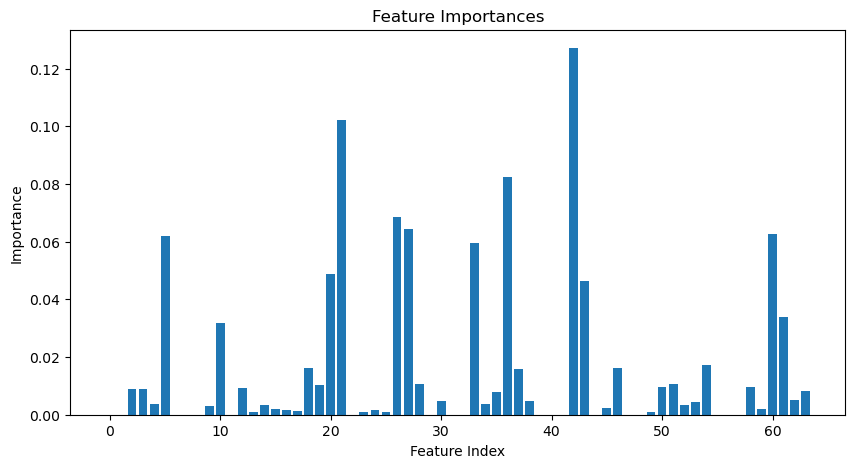

In [21]:
# 문제 3: 피처 중요도 

importances = clf_default.feature_importances_

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importances")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

## 문제 4: train_test_split 비율 변경
- `train_test_split`을 사용하여 학습 데이터와 테스트 데이터를 **70:30** 비율로 나누세요.
- 기존의 80:20 비율과 비교하여 정확도를 출력하세요.

In [57]:
# 문제 4: train_test_split 비율 변경

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

digits = load_digits()
X, y = digits.data, digits.target

# 80:20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.2, random_state=42)

clf_80 = DecisionTreeClassifier(random_state=42)
clf_80.fit(X_train_80, y_train_80)
acc_80 = accuracy_score(y_test_20, clf_80.predict(X_test_20))

# 70:20
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.3, random_state=42)

clf_70 = DecisionTreeClassifier(random_state=42)
clf_70.fit(X_train_70, y_train_70)
acc_70 = accuracy_score(y_test_30, clf_70.predict(X_test_30))

# 비교 출력
print(f"기존 80:20 정확도: {acc_80:.4f}")
print(f"70:30 정확도: {acc_70:.4f}")


기존 80:20 정확도: 0.8417
70:30 정확도: 0.8426


## 문제 5: GridSearchCV를 활용한 최적 하이퍼파라미터 찾기
- `GridSearchCV`를 사용하여 `max_depth`와 `min_samples_split`에 대한 최적의 하이퍼파라미터를 찾으세요.
- 최적의 하이퍼파라미터와 최고 정확도를 출력하세요.

In [59]:
# 문제 5: GridSearchCV를 활용한 최적 하이퍼파라미터 찾기
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최고 정확도:", f"{grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_acc = accuracy_score(y_test, best_model.predict(X_test))
print("테스트 정확도:", f"{test_acc:.4f}")


최적 하이퍼파라미터: {'max_depth': 3, 'min_samples_split': 2}
최고 정확도: 0.9224
테스트 정확도: 0.9444


# **2. 앙상블**

## **1) wine 데이터셋 로드 및 훈련/테스트 분리**
wine 데이터를 불러온 후, 훈련 세트와 테스트 세트로 나눠주세요.
*   test_size = 0.25
*   random_state = 11

In [61]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# 데이터 로드 및 분리
## 답안 ##

wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11)

## **2) SVC, RandomForest, GradientBoosting 모델 학습 및 정확도 평가**
다음 모델을 사용해 개별 학습/예측/정확도 평가를 진행하세요.
*   서포트 벡터 머신: probability=True
*   랜덤 포레스트: n_estimators=100, random_state=11
*   GradientBoostingClassifier: random_state=11




In [31]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

svc = SVC(probability=True)
rf = RandomForestClassifier(n_estimators=100, random_state=11)
gb = GradientBoostingClassifier(random_state=11)

## 답안 
svc.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

svc_acc = accuracy_score(y_test, svc.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))
gb_acc = accuracy_score(y_test, gb.predict(X_test))

print("SVC 정확도:", svc_acc)
print("Random Forest 정확도:", rf_acc)
print("Gradient Boosting 정확도:", gb_acc)

SVC 정확도: 0.8
Random Forest 정확도: 0.9777777777777777
Gradient Boosting 정확도: 0.9555555555555556


## **3) 하드 보팅 분류기 생성 및 평가**
위에서 만든 모델 3개를 기반으로 하드 보팅 방식의 분류기를 만들고, 학습 및 테스트 정확도를 출력하세요.

In [63]:
from sklearn.ensemble import VotingClassifier

# 하드 보팅
## 답안 ##

from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators=[('svc', svc), ('rf', rf), ('gb', gb)], voting='hard')

voting_clf.fit(X_train, y_train)
voting_acc = accuracy_score(y_test, voting_clf.predict(X_test))

print("하드 보팅 분류기 정확도:", voting_acc)

하드 보팅 분류기 정확도: 0.9555555555555556


## **4) 소프트 보팅 분류기 생성 및 평가**
같은 모델 3개로 소프트 보팅 방식의 분류기를 만들어서 학습/평가하세요.

In [65]:
# 소프트 보팅
## 답안 
# 소프트 보팅 분류기
soft_voting_clf = VotingClassifier(estimators=[('svc', svc), ('rf', rf), ('gb', gb)], voting='soft')

soft_voting_clf.fit(X_train, y_train)
soft_voting_acc = accuracy_score(y_test, soft_voting_clf.predict(X_test))

print("소프트 보팅 분류기 정확도:", soft_voting_acc)


소프트 보팅 분류기 정확도: 0.9555555555555556


## **5) OOB 평가**
다음 조건에 맞춰 BaggingClassifier를 사용하여 OOB 평가를 수행하세요.

*   Base 모델: GradientBoostingClassifier()
*   n_estimators = 50
*   bootstrap=True

OOB 점수를 출력하세요.

In [67]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier

bagging_clf = BaggingClassifier(estimator= GradientBoostingClassifier(), n_estimators=50, bootstrap=True, oob_score=True, random_state=42)

bagging_clf.fit(X_train, y_train)
print("OOB 점수:", bagging_clf.oob_score_)


OOB 점수: 0.9624060150375939


# **3. 랜덤 포레스트(Random Forest)**

**1) 사이킷런의 load_wine 데이터셋을 RandomForestClassifier을 이용해 예측하시오.**

In [69]:
# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

wine = load_wine()
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 1.0000


**2) load_wine 데이터셋을 이용해 GradientBoostingClassifier 모델을 학습하고, GridSearchCV를 활용해 최적의 하이퍼 파라미터를 찾으시오.**

✅ 조건
1. 데이터셋: load_wine() 사용
2. 훈련 데이터(80%) / 테스트 데이터(20%)로 분리
3. 하이퍼파라미터 튜닝(GridSearchCV 사용)
4. learning_rate: [0.01, 0.1, 0.2]
   n_estimators: [100, 200, 300]
   max_depth: [3, 5, 7]
5. 최적의 하이퍼파라미터를 찾은 후 모델 학습 & 평가
6. 테스트 데이터에서 정확도를 출력

✅ 참고사항

실행 시간이 오래 소요될 수 있습니다!

In [71]:
# 필요한 라이브러리 임포트
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

wine = load_wine()
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


params = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7]
}

gb_clf = GradientBoostingClassifier(random_state=42)
grid_cv = GridSearchCV(gb_clf, param_grid=params, cv=5, n_jobs=-1)

grid_cv.fit(X_train, y_train)

print('최적 하이퍼파라미터:', grid_cv.best_params_)

y_pred = grid_cv.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('예측 정확도: {0:.4f}'.format(accuracy))


최적 하이퍼파라미터: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
예측 정확도: 0.9444


## **서포트 벡터 머신(SVM)**

**1) 가우시안 RBF 커널을 사용하여 gamma 값이 1이고, 하이퍼파라미터 C의 값이 0.001인 SVM 분류기를 만드시오.**


In [73]:
# 필요한 라이브러리 임포트
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=200, noise=0.25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


rbf_kernel_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', gamma=10, C=0.001))
])

# 모델학습
rbf_kernel_svm_clf.fit(X_train, y_train)

# 정확도 평가
train_acc = rbf_kernel_svm_clf.score(X_train, y_train)
test_acc = rbf_kernel_svm_clf.score(X_test, y_test)

print("SVM 훈련 정확도:", train_acc)
print("SVM 테스트 정확도:", test_acc)

SVM 훈련 정확도: 0.5266666666666666
SVM 테스트 정확도: 0.42
